# House Prices EDA

Exploratory Data Analysis for Kaggle House Prices - Advanced Regression Techniques. The goal is to understand the target, missing values, feature distributions, and signals that should be used in preprocessing and modeling.

## Plan

1. Load train, test, and sample submission.
2. Inspect shapes, columns, duplicates, and missing values.
3. Analyze `SalePrice` distribution and log transform.
4. Explore important numeric and categorical features.
5. Compare train/test distributions.
6. Create simple engineered features and summarize modeling insights.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 3)

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "data").exists() else CURRENT_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

PROJECT_ROOT, DATA_DIR

(PosixPath('/Users/medvedvalexey/PycharmProjects/House_Prices_Final_Project'),
 PosixPath('/Users/medvedvalexey/PycharmProjects/House_Prices_Final_Project/data'))

## Load Data

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Basic Checks

In [5]:
overview = pd.DataFrame({
    "dataset": ["train", "test", "sample_submission"],
    "rows": [len(train), len(test), len(sample_submission)],
    "columns": [train.shape[1], test.shape[1], sample_submission.shape[1]],
    "duplicate_rows": [train.duplicated().sum(), test.duplicated().sum(), sample_submission.duplicated().sum()],
})
overview

,dataset,rows,columns,duplicate_rows
0,train,1460,81,0
1,test,1459,80,0
2,sample_submission,1459,2,0


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
train.describe().T.sort_values("std", ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.196,79442.503,34900.0,129975.00,163000.0,214000.00,755000.0
LotArea,1460.0,10516.828,9981.265,1300.0,7553.50,9478.5,11601.50,215245.0
GrLivArea,1460.0,1515.464,525.480,334.0,1129.50,1464.0,1776.75,5642.0
MiscVal,1460.0,43.489,496.123,0.0,0.00,0.0,0.00,15500.0
BsmtFinSF1,1460.0,443.640,456.098,0.0,0.00,383.5,712.25,5644.0
BsmtUnfSF,1460.0,567.240,441.867,0.0,223.00,477.5,808.00,2336.0
TotalBsmtSF,1460.0,1057.429,438.705,0.0,795.75,991.5,1298.25,6110.0
2ndFlrSF,1460.0,346.992,436.528,0.0,0.00,0.0,728.00,2065.0
Id,1460.0,730.500,421.610,1.0,365.75,730.5,1095.25,1460.0
1stFlrSF,1460.0,1162.627,386.588,334.0,882.00,1087.0,1391.25,4692.0


## Target: SalePrice

In [8]:
train["SalePrice"].describe()

count      1460.000
mean     180921.196
std       79442.503
min       34900.000
25%      129975.000
50%      163000.000
75%      214000.000
max      755000.000
Name: SalePrice, dtype: float64

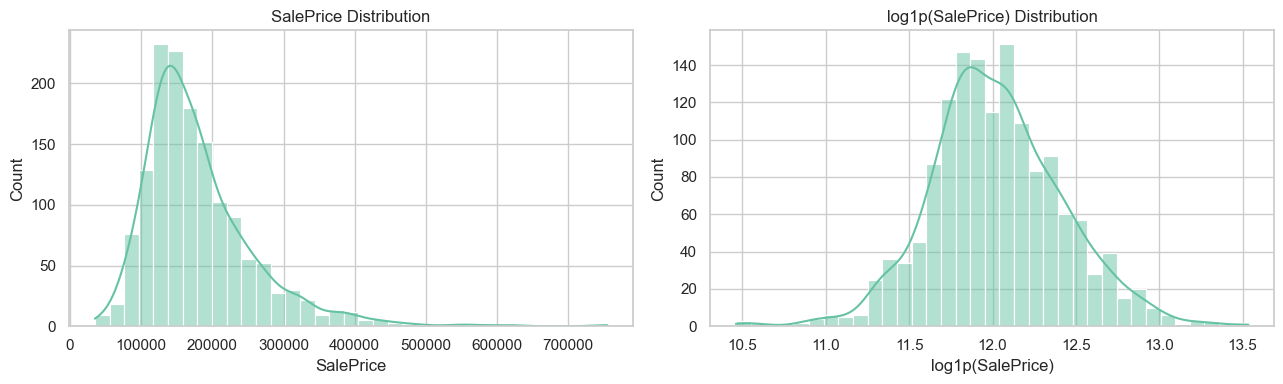

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(train["SalePrice"], kde=True, bins=35, ax=axes[0])
axes[0].set_title("SalePrice Distribution")

sns.histplot(np.log1p(train["SalePrice"]), kde=True, bins=35, ax=axes[1])
axes[1].set_title("log1p(SalePrice) Distribution")
axes[1].set_xlabel("log1p(SalePrice)")

plt.tight_layout()

In [10]:
print(f"SalePrice skew: {train['SalePrice'].skew():.3f}")
print(f"log1p(SalePrice) skew: {np.log1p(train['SalePrice']).skew():.3f}")

SalePrice skew: 1.883
log1p(SalePrice) skew: 0.121


## Missing Values

In [11]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.isna().sum()
    return (
        pd.DataFrame({
            "missing_count": missing,
            "missing_percent": missing / len(df) * 100,
            "dtype": df.dtypes.astype(str),
        })
        .query("missing_count > 0")
        .sort_values("missing_percent", ascending=False)
    )

missing_train = missing_report(train)
missing_test = missing_report(test)
missing_train.head(25)

,missing_count,missing_percent,dtype
PoolQC,1453,99.521,str
MiscFeature,1406,96.301,str
Alley,1369,93.767,str
Fence,1179,80.753,str
MasVnrType,872,59.726,str
FireplaceQu,690,47.260,str
LotFrontage,259,17.740,float64
GarageType,81,5.548,str
GarageYrBlt,81,5.548,float64
GarageFinish,81,5.548,str


In [12]:
missing_test.head(25)

,missing_count,missing_percent,dtype
PoolQC,1456,99.794,str
MiscFeature,1408,96.504,str
Alley,1352,92.666,str
Fence,1169,80.123,str
MasVnrType,894,61.275,str
FireplaceQu,730,50.034,str
LotFrontage,227,15.559,float64
GarageCond,78,5.346,str
GarageYrBlt,78,5.346,float64
GarageQual,78,5.346,str


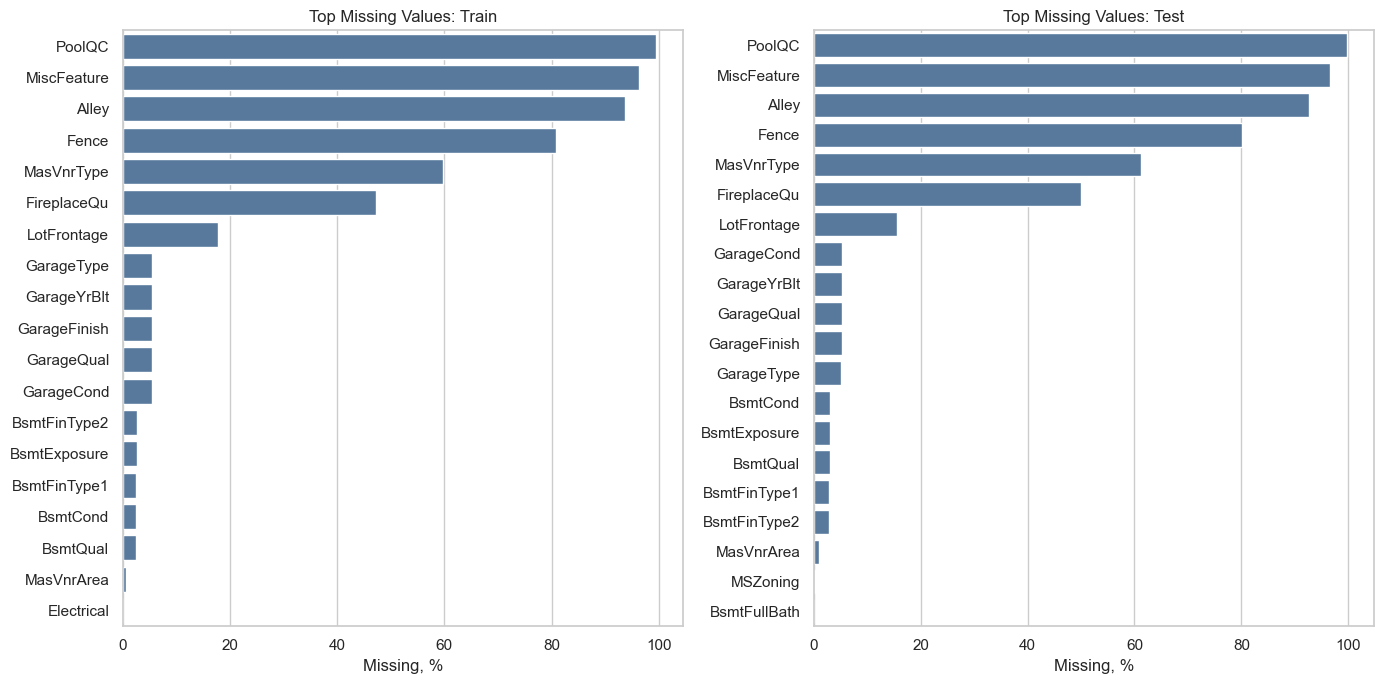

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, report, title in zip(axes, [missing_train.head(20), missing_test.head(20)], ["Train", "Test"]):
    sns.barplot(data=report.reset_index(), x="missing_percent", y="index", ax=ax, color="#4C78A8")
    ax.set_title(f"Top Missing Values: {title}")
    ax.set_xlabel("Missing, %")
    ax.set_ylabel("")

plt.tight_layout()

## Numeric Features

In [14]:
numeric_columns = train.select_dtypes(include=np.number).columns.drop(["Id", "SalePrice"])
correlations = train[numeric_columns.tolist() + ["SalePrice"]].corr(numeric_only=True)["SalePrice"].drop("SalePrice")
top_numeric = correlations.abs().sort_values(ascending=False).head(15).index.tolist()
pd.DataFrame({"correlation_with_sale_price": correlations.loc[top_numeric]}).sort_values("correlation_with_sale_price", ascending=False)

,correlation_with_sale_price
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534
YearBuilt,0.523
YearRemodAdd,0.507


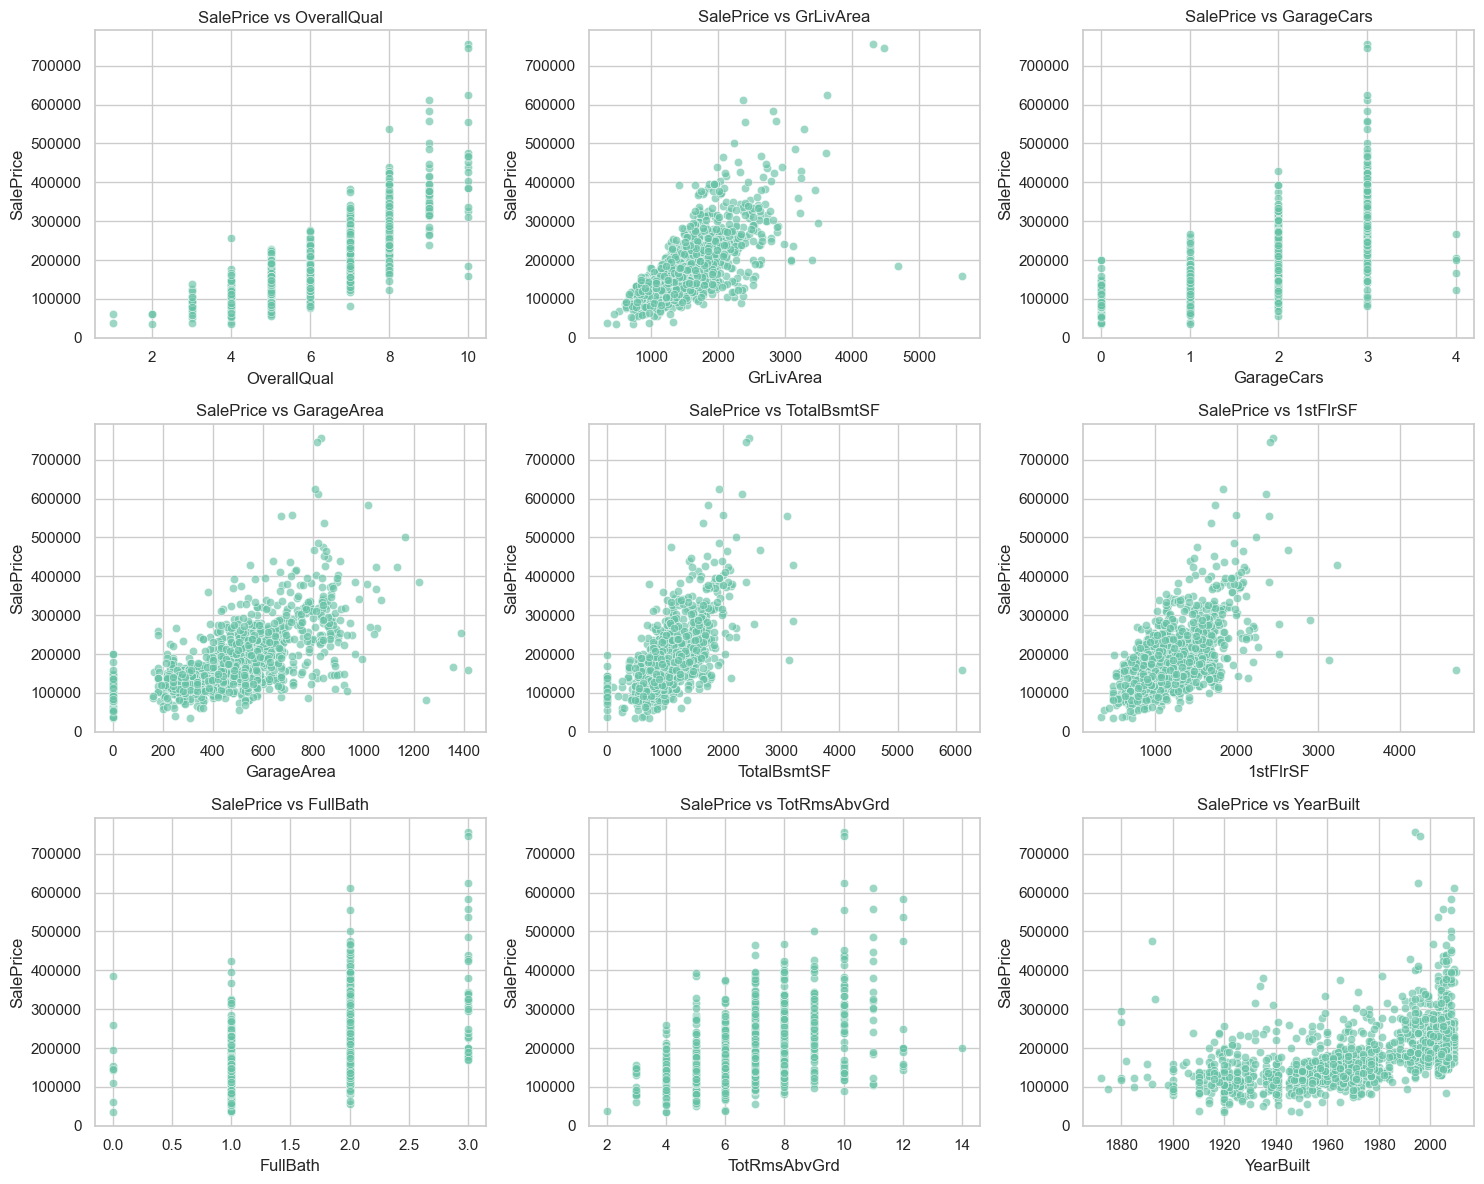

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for ax, column in zip(axes, top_numeric[:9]):
    sns.scatterplot(data=train, x=column, y="SalePrice", ax=ax, alpha=0.65)
    ax.set_title(f"SalePrice vs {column}")

plt.tight_layout()

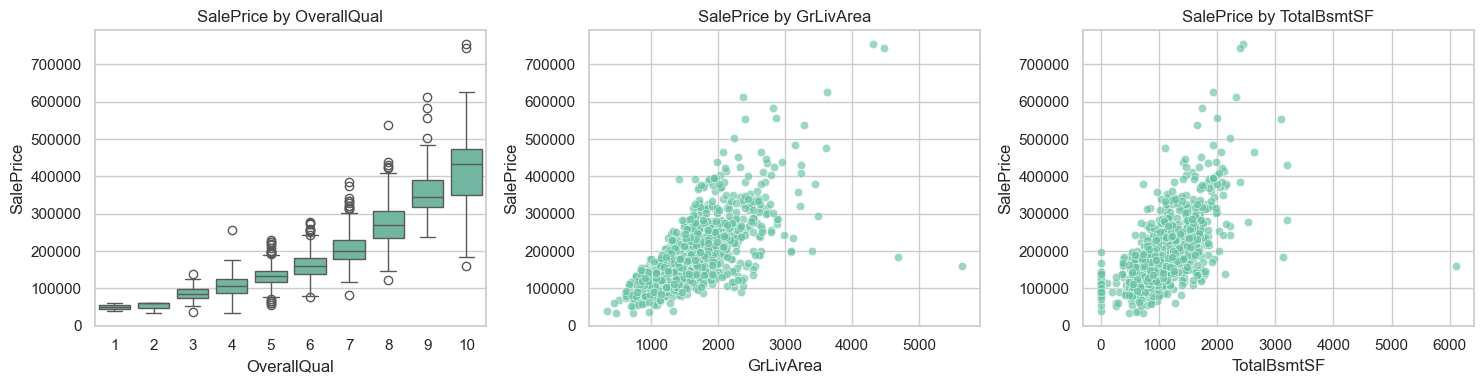

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ["OverallQual", "GrLivArea", "TotalBsmtSF"]):
    if column == "OverallQual":
        sns.boxplot(data=train, x=column, y="SalePrice", ax=ax)
    else:
        sns.scatterplot(data=train, x=column, y="SalePrice", ax=ax, alpha=0.65)
    ax.set_title(f"SalePrice by {column}")

plt.tight_layout()

## Categorical Features

In [17]:
categorical_columns = train.select_dtypes(include="object").columns
category_summary = pd.DataFrame({
    "unique_values": train[categorical_columns].nunique(),
    "missing_percent": train[categorical_columns].isna().mean() * 100,
}).sort_values(["missing_percent", "unique_values"], ascending=False)
category_summary.head(20)

/var/folders/bk/q068pvpx5979b18kqck5n23r0000gn/T/ipykernel_48584/219091567.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train.select_dtypes(include="object").columns


,unique_values,missing_percent
PoolQC,3,99.521
MiscFeature,4,96.301
Alley,2,93.767
Fence,4,80.753
MasVnrType,3,59.726
FireplaceQu,5,47.260
GarageType,6,5.548
GarageQual,5,5.548
GarageCond,5,5.548
GarageFinish,3,5.548


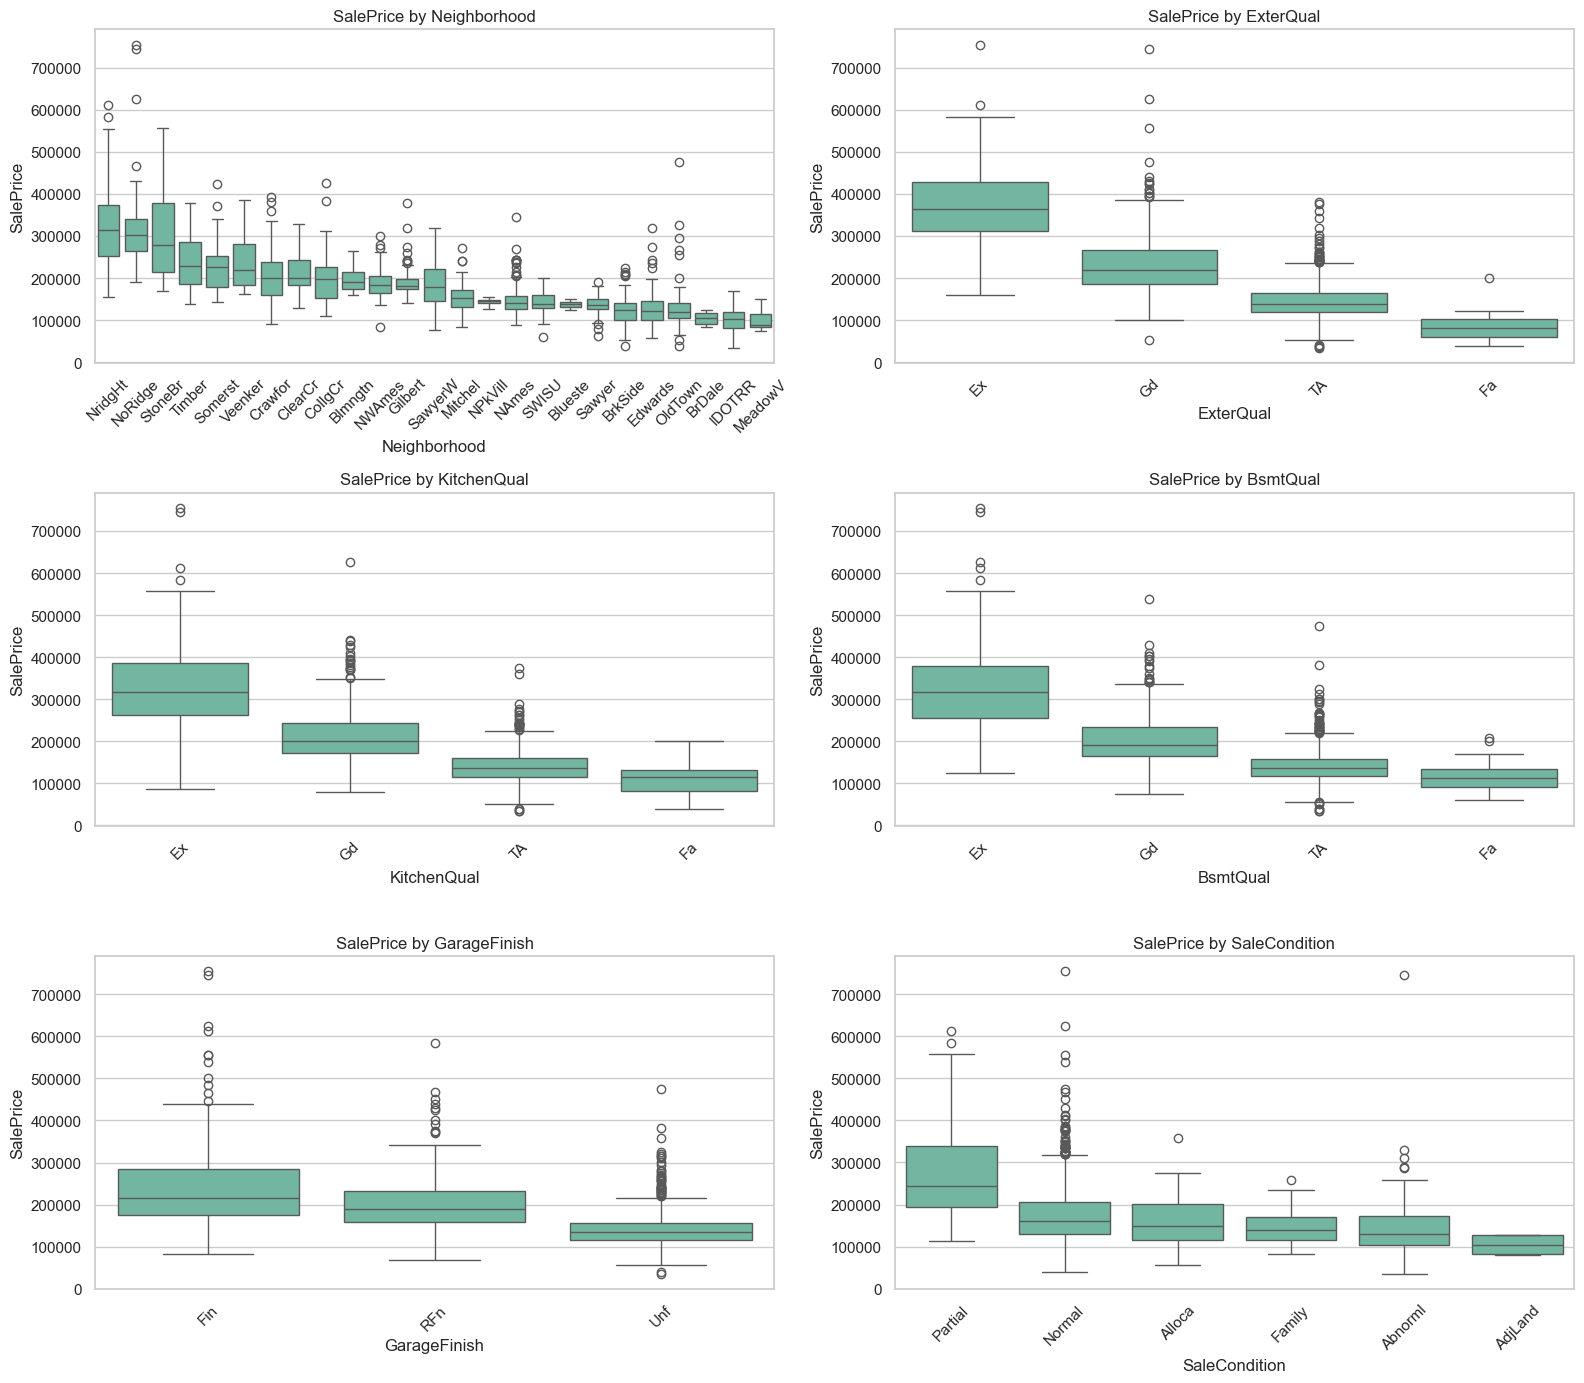

In [18]:
important_categories = ["Neighborhood", "ExterQual", "KitchenQual", "BsmtQual", "GarageFinish", "SaleCondition"]
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()

for ax, column in zip(axes, important_categories):
    order = train.groupby(column)["SalePrice"].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=column, y="SalePrice", order=order, ax=ax)
    ax.set_title(f"SalePrice by {column}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

## Simple Feature Engineering

In [19]:
def add_eda_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["TotalSF"] = result["TotalBsmtSF"].fillna(0) + result["1stFlrSF"].fillna(0) + result["2ndFlrSF"].fillna(0)
    result["TotalBathrooms"] = result["FullBath"].fillna(0) + 0.5 * result["HalfBath"].fillna(0) + result["BsmtFullBath"].fillna(0) + 0.5 * result["BsmtHalfBath"].fillna(0)
    result["TotalPorchSF"] = result["OpenPorchSF"].fillna(0) + result["EnclosedPorch"].fillna(0) + result["3SsnPorch"].fillna(0) + result["ScreenPorch"].fillna(0) + result["WoodDeckSF"].fillna(0)
    result["HouseAge"] = result["YrSold"] - result["YearBuilt"]
    result["RemodAge"] = result["YrSold"] - result["YearRemodAdd"]
    result["HasGarage"] = (result["GarageArea"].fillna(0) > 0).astype(int)
    result["HasBasement"] = (result["TotalBsmtSF"].fillna(0) > 0).astype(int)
    result["HasFireplace"] = (result["Fireplaces"].fillna(0) > 0).astype(int)
    return result

train_eda = add_eda_features(train)
test_eda = add_eda_features(test)
train_eda[["TotalSF", "TotalBathrooms", "TotalPorchSF", "HouseAge", "RemodAge", "HasGarage", "HasBasement", "HasFireplace"]].head()

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodAge,HasGarage,HasBasement,HasFireplace
0,2566,3.5,61,5,5,1,1,0
1,2524,2.5,298,31,31,1,1,1
2,2706,3.5,42,7,6,1,1,1
3,2473,2.0,307,91,36,1,1,1
4,3343,3.5,276,8,8,1,1,1


In [20]:
engineered_columns = ["TotalSF", "TotalBathrooms", "TotalPorchSF", "HouseAge", "RemodAge"]
engineered_corr = train_eda[engineered_columns + ["SalePrice"]].corr(numeric_only=True)["SalePrice"].drop("SalePrice")
engineered_corr.sort_values(ascending=False)

TotalSF           0.782
TotalBathrooms    0.632
TotalPorchSF      0.391
RemodAge         -0.509
HouseAge         -0.523
Name: SalePrice, dtype: float64

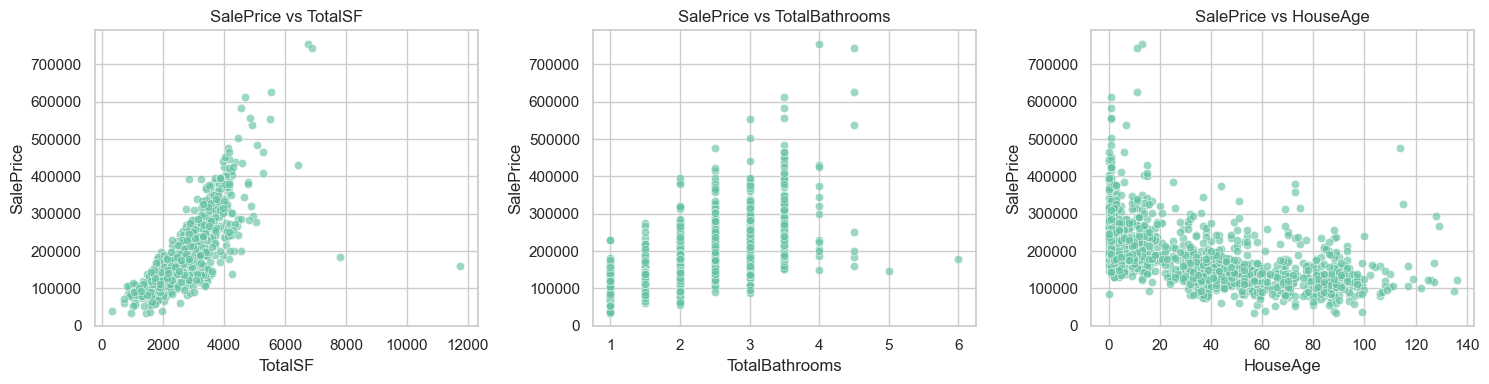

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ["TotalSF", "TotalBathrooms", "HouseAge"]):
    sns.scatterplot(data=train_eda, x=column, y="SalePrice", ax=ax, alpha=0.65)
    ax.set_title(f"SalePrice vs {column}")

plt.tight_layout()

## Train vs Test Comparison

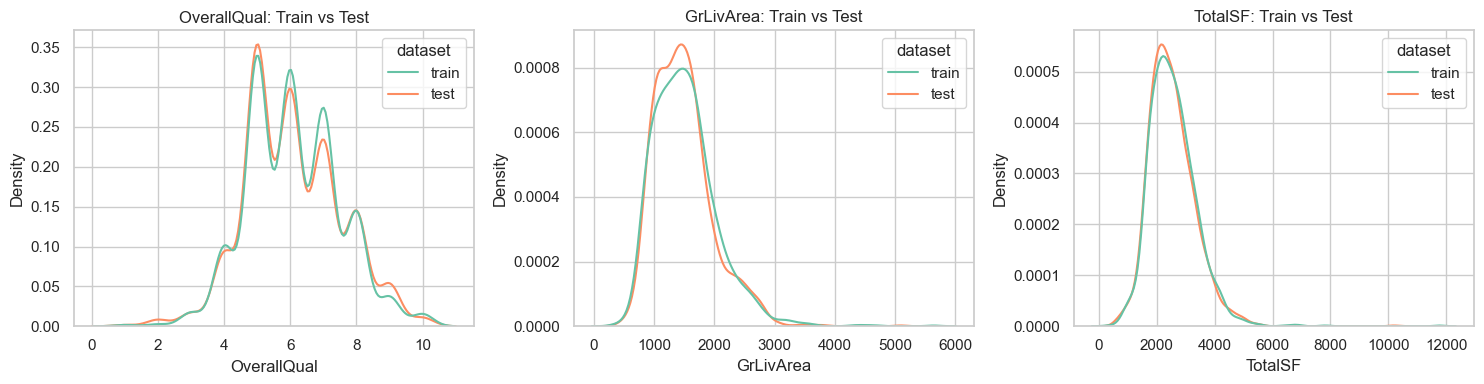

In [22]:
combined = pd.concat([train_eda.assign(dataset="train"), test_eda.assign(dataset="test")], ignore_index=True, sort=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ["OverallQual", "GrLivArea", "TotalSF"]):
    sns.kdeplot(data=combined, x=column, hue="dataset", common_norm=False, ax=ax)
    ax.set_title(f"{column}: Train vs Test")

plt.tight_layout()

## Correlation Heatmap

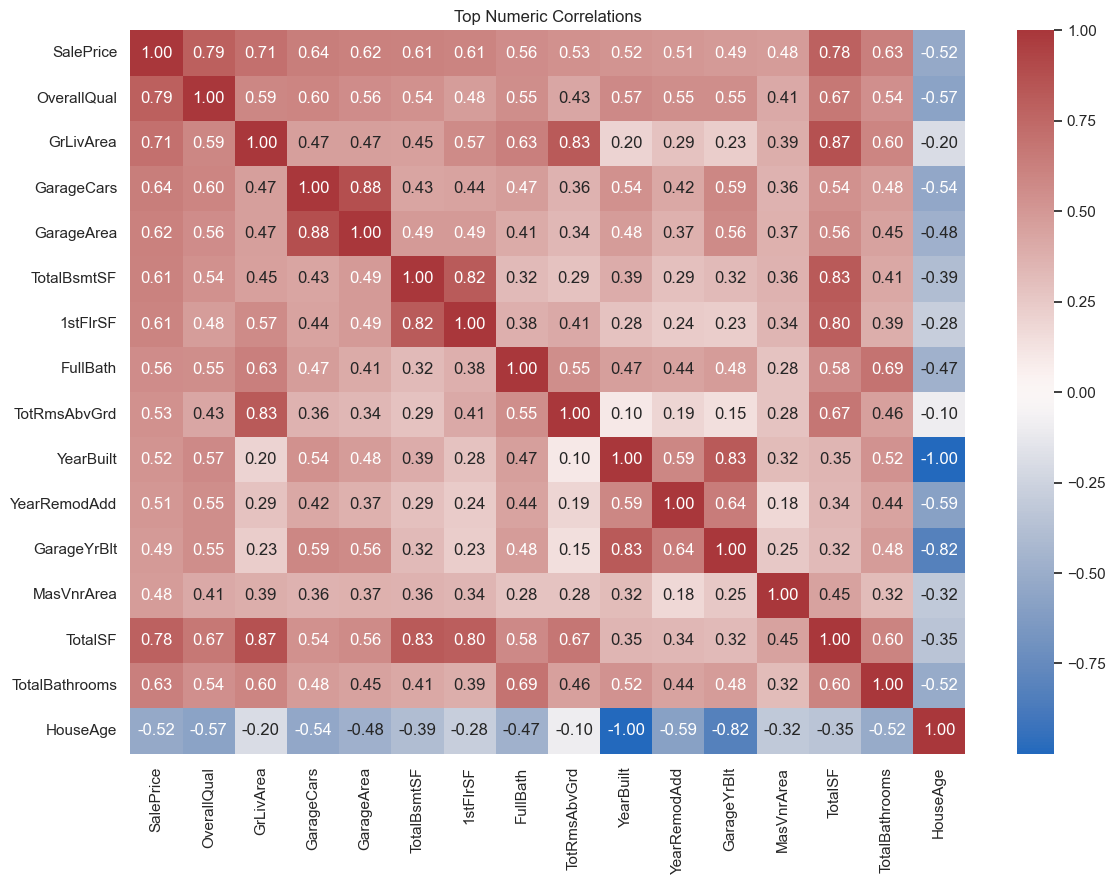

In [23]:
heatmap_columns = ["SalePrice"] + correlations.abs().sort_values(ascending=False).head(12).index.tolist() + ["TotalSF", "TotalBathrooms", "HouseAge"]
heatmap_columns = list(dict.fromkeys(heatmap_columns))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(train_eda[heatmap_columns].corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Top Numeric Correlations")
plt.tight_layout()

## Main EDA Insights

- `SalePrice` is right-skewed; `log1p(SalePrice)` is much closer to a normal shape, which matches Kaggle RMSLE.
- The strongest numeric signal is house quality and size: `OverallQual`, `GrLivArea`, garage/basement area, and total square footage.
- Many missing values are meaningful absence markers: no alley, no pool, no fence, no fireplace quality, no garage, or no basement.
- `Neighborhood`, exterior quality, kitchen quality, basement quality, and garage finish show strong price differences.
- Engineered features like `TotalSF`, `TotalBathrooms`, `HouseAge`, and availability flags are useful for both classic ML and DL.
- Classic ML models are a strong baseline for this tabular problem; DL is included as a learning extension rather than an expected guaranteed winner.